# Análise de Engajamento em Redes Sociais (2015–2024)

**Disciplina:** Linguagem de Programação: Análise e Visualização de Dados com Python
**Avaliação:** G1 · Tema 20: Redes Sociais e Engajamento Digital
**Aluno:** Marcelo de Moura Maia Júnior

## 1. Introdução

As redes sociais viraram um dos principais canais de comunicação entre marcas, criadores de conteúdo e o público. Entender **o que faz uma publicação engajar** ajuda a decidir em qual plataforma investir, qual formato usar e em que horário publicar.

O objetivo deste notebook é analisar uma base de publicações de 2015 a 2024 para responder às perguntas orientadoras do projeto:

1. Quais plataformas apresentam maior engajamento?
2. Quais tipos de conteúdo possuem melhor desempenho?
3. Existem horários mais favoráveis para publicações?
4. Como o número de seguidores evoluiu ao longo do tempo?
5. Existe relação entre frequência de postagem e alcance?
6. Quais campanhas (combinações de perfil e formato) apresentaram melhores resultados?
7. Quais métricas são mais relevantes para o engajamento?

## 2. Contextualização do marketing digital

No marketing digital, o número de seguidores sozinho diz pouco. O que as empresas acompanham são métricas de **interação**:

- **Curtidas, comentários e compartilhamentos:** mostram que o público reagiu ao conteúdo. Compartilhamentos e comentários costumam valer mais, porque exigem mais esforço do usuário.
- **Visualizações:** quantas vezes o conteúdo foi exibido (a mesma pessoa pode ver mais de uma vez).
- **Alcance:** quantas pessoas diferentes viram o conteúdo.
- **Taxa de engajamento:** percentual que resume quanto o público interagiu em relação ao tamanho da audiência.

Cada plataforma tem seu público e seus formatos (vídeos curtos no TikTok, stories no Instagram, conteúdo profissional no LinkedIn), por isso faz sentido comparar plataformas, formatos e horários.

## 3. Explicação da base de dados

A base `simulacao_redes_sociais_brasil.csv` foi fornecida pelo professor e contém dados **simulados** de publicações.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Quando a publicação foi feita |
| `plataforma` | Facebook, Instagram, LinkedIn, TikTok, X ou YouTube |
| `perfil` | Perfil que publicou (EducaOnline, GamesBR, ModaHoje, TechBrasil) |
| `categoria` | Tema do conteúdo (Educação, Entretenimento, Games, Tecnologia) |
| `tipo_conteudo` | Formato: Vídeo, Imagem, Stories, Live ou Carrossel |
| `seguidores` | Seguidores do perfil no momento da publicação |
| `curtidas`, `comentarios`, `compartilhamentos` | Interações recebidas |
| `visualizacoes` | Número de visualizações |
| `alcance` | Pessoas alcançadas |
| `taxa_engajamento` | Percentual de engajamento da publicação |
| `horario_publicacao` | Horário da postagem (08:00, 12:00, 18:00 ou 21:00) |

## 4. Leitura dos dados

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PASTA_DADOS = Path("../dados")
PASTA_IMAGENS = Path("../imagens")
PASTA_BANCO = Path("../database")
PASTA_IMAGENS.mkdir(exist_ok=True)
PASTA_BANCO.mkdir(exist_ok=True)

# cada plataforma tem sempre a mesma cor em todos os gráficos
CORES_PLATAFORMA = {
    "Facebook": "#2a78d6",
    "Instagram": "#eb6834",
    "LinkedIn": "#1baf7a",
    "TikTok": "#eda100",
    "X": "#e87ba4",
    "YouTube": "#008300",
}
COR_PRINCIPAL = "#2a78d6"


def salvar_grafico(nome):
    plt.savefig(PASTA_IMAGENS / f"{nome}.png", dpi=120, bbox_inches="tight")


def formatar(valor, casas=0):
    texto = f"{valor:,.{casas}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")

In [2]:
df = pd.read_csv(PASTA_DADOS / "simulacao_redes_sociais_brasil.csv", encoding="utf-8-sig")

print(f"A base tem {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

A base tem 4440 linhas e 15 colunas.

,ano,mes,data,plataforma,perfil,categoria,tipo_conteudo,seguidores,curtidas,comentarios,compartilhamentos,visualizacoes,alcance,taxa_engajamento,horario_publicacao
0,2015,1,2015-01-01,LinkedIn,EducaOnline,Entretenimento,Vídeo,608562,60519,4204,8462,46688,601986,3.31,08:00
1,2015,1,2015-01-01,TikTok,GamesBR,Tecnologia,Imagem,733755,77926,199,7096,1635721,1798994,7.68,08:00
2,2015,1,2015-01-01,LinkedIn,GamesBR,Educação,Stories,986048,48692,4437,2047,1799255,2354880,4.79,18:00
3,2015,1,2015-01-01,YouTube,ModaHoje,Games,Imagem,814782,49169,3738,1740,195735,2072736,3.26,12:00
4,2015,1,2015-01-01,Facebook,TechBrasil,Tecnologia,Live,270513,585,2480,7029,1096820,2457502,3.48,21:00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 4440 non-null   int64  
 1   mes                 4440 non-null   int64  
 2   data                4440 non-null   str    
 3   plataforma          4440 non-null   str    
 4   perfil              4440 non-null   str    
 5   categoria           4440 non-null   str    
 6   tipo_conteudo       4440 non-null   str    
 7   seguidores          4440 non-null   int64  
 8   curtidas            4440 non-null   int64  
 9   comentarios         4440 non-null   int64  
 10  compartilhamentos   4440 non-null   int64  
 11  visualizacoes       4440 non-null   int64  
 12  alcance             4440 non-null   int64  
 13  taxa_engajamento    4440 non-null   float64
 14  horario_publicacao  4440 non-null   str    
dtypes: float64(1), int64(8), str(6)
memory usage: 520.4 KB

## 5. Limpeza e preparação

Antes de analisar, é preciso verificar se a base tem valores nulos, linhas duplicadas, tipos errados ou valores que não fazem sentido.

In [4]:
print("Valores nulos por coluna:")
print(df.isna().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())

Valores nulos por coluna:
ano                   0
mes                   0
data                  0
plataforma            0
perfil                0
categoria             0
tipo_conteudo         0
seguidores            0
curtidas              0
comentarios           0
compartilhamentos     0
visualizacoes         0
alcance               0
taxa_engajamento      0
horario_publicacao    0
dtype: int64

Linhas duplicadas: 0

In [5]:
for coluna in ["plataforma", "perfil", "categoria", "tipo_conteudo", "horario_publicacao"]:
    print(f"{coluna}: {sorted(df[coluna].unique())}")

plataforma: ['Facebook', 'Instagram', 'LinkedIn', 'TikTok', 'X', 'YouTube']
perfil: ['EducaOnline', 'GamesBR', 'ModaHoje', 'TechBrasil']
categoria: ['Educação', 'Entretenimento', 'Games', 'Tecnologia']
tipo_conteudo: ['Carrossel', 'Imagem', 'Live', 'Stories', 'Vídeo']
horario_publicacao: ['08:00', '12:00', '18:00', '21:00']

A coluna `data` veio como texto e o horário também. Vamos converter a data para `datetime`, extrair a hora como número e transformar as colunas de texto com poucos valores em `category`.

In [6]:
df["data"] = pd.to_datetime(df["data"])
df["hora"] = df["horario_publicacao"].str[:2].astype(int)

colunas_categoricas = ["plataforma", "perfil", "categoria", "tipo_conteudo"]
for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype("category")

df.dtypes

ano                            int64
mes                            int64
data                  datetime64[us]
plataforma                  category
perfil                      category
categoria                   category
tipo_conteudo               category
seguidores                     int64
curtidas                       int64
comentarios                    int64
compartilhamentos              int64
visualizacoes                  int64
alcance                        int64
taxa_engajamento             float64
horario_publicacao               str
hora                           int64
dtype: object

In [7]:
colunas_numericas = ["seguidores", "curtidas", "comentarios", "compartilhamentos",
                     "visualizacoes", "alcance", "taxa_engajamento"]

df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
seguidores,"4,440.00","500,083.76","284,372.59","1,345.00","253,730.00","502,211.50","743,244.75","999,977.00"
curtidas,"4,440.00","40,093.57","22,879.70",170.00,"20,187.00","39,959.00","59,847.50","79,983.00"
comentarios,"4,440.00","2,489.47","1,446.16",10.00,"1,230.50","2,496.50","3,769.75","4,998.00"
compartilhamentos,"4,440.00","4,992.84","2,876.10",10.00,"2,516.75","4,980.00","7,459.50","9,998.00"
visualizacoes,"4,440.00","1,007,836.40","573,044.02","2,554.00","518,828.25","1,016,972.50","1,502,862.75","1,998,805.00"
alcance,"4,440.00","1,262,404.42","718,506.38","1,853.00","640,140.25","1,275,359.50","1,883,703.25","2,499,265.00"
taxa_engajamento,"4,440.00",6.24,3.34,0.50,3.32,6.22,9.09,12.00


Agora alguns testes de consistência: valores negativos, taxa fora do intervalo e publicações com mais interações do que pessoas alcançadas (o que não deveria acontecer).

In [8]:
print("Valores negativos:", (df[colunas_numericas] < 0).sum().sum())

taxa_invalida = (df["taxa_engajamento"] < 0) | (df["taxa_engajamento"] > 100)
print("Taxa de engajamento fora de 0-100%:", taxa_invalida.sum())

interacoes = df["curtidas"] + df["comentarios"] + df["compartilhamentos"]
df["inconsistente"] = interacoes > df["alcance"]
print("Publicações com mais interações do que alcance:", df["inconsistente"].sum(),
      f"({df['inconsistente'].mean():.1%} da base)")

Valores negativos: 0
Taxa de engajamento fora de 0-100%: 0
Publicações com mais interações do que alcance: 86 (1.9% da base)

In [9]:
def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()


df[colunas_numericas].apply(contar_outliers).rename("outliers (IQR)")

seguidores           0
curtidas             0
comentarios          0
compartilhamentos    0
visualizacoes        0
alcance              0
taxa_engajamento     0
Name: outliers (IQR), dtype: int64

In [10]:
media_todas = df["taxa_engajamento"].mean()
media_sem_inconsistentes = df.loc[~df["inconsistente"], "taxa_engajamento"].mean()

print(f"Engajamento médio com todas as linhas: {media_todas:.2f}%")
print(f"Engajamento médio sem as inconsistentes: {media_sem_inconsistentes:.2f}%")

Engajamento médio com todas as linhas: 6.24%
Engajamento médio sem as inconsistentes: 6.24%

**Decisões da limpeza:**

- A base não tem valores nulos, duplicados, negativos nem outliers pelo critério do IQR.
- Foram encontradas publicações com mais interações do que alcance. Como elas são poucas e **não mudam o resultado** (a média praticamente não se altera), elas foram mantidas, mas ficaram marcadas na coluna `inconsistente` para quem quiser filtrar.
- Repare também que a `taxa_engajamento` não é calculada a partir das curtidas/comentários/alcance da própria linha (é um dado independente da simulação). Por isso a análise usa a taxa como ela veio e cria uma métrica própria de interações.

## 6. Engenharia de atributos

Novas colunas criadas a partir das existentes para facilitar a análise:

In [11]:
df["interacoes"] = df["curtidas"] + df["comentarios"] + df["compartilhamentos"]
df["trimestre"] = df["data"].dt.quarter
df["ano_mes"] = df["data"].dt.to_period("M").astype(str)

nomes_meses = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
               7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"}
df["nome_mes"] = df["mes"].map(nomes_meses)

df["faixa_seguidores"] = pd.cut(
    df["seguidores"],
    bins=[0, 250_000, 500_000, 750_000, 1_000_000],
    labels=["até 250 mil", "250-500 mil", "500-750 mil", "750 mil-1 mi"],
)

# conteúdo viral = os 5% de publicações com mais visualizações
limite_viral = df["visualizacoes"].quantile(0.95)
df["viral"] = df["visualizacoes"] >= limite_viral

print(f"Limite para ser considerado viral: {formatar(limite_viral)} visualizações")
print(f"Publicações virais: {df['viral'].sum()}")
df[["data", "plataforma", "interacoes", "trimestre", "nome_mes", "faixa_seguidores", "viral"]].head()

Limite para ser considerado viral: 1.896.704 visualizações
Publicações virais: 222

,data,plataforma,interacoes,trimestre,nome_mes,faixa_seguidores,viral
0,2015-01-01,LinkedIn,73185,1,Jan,500-750 mil,False
1,2015-01-01,TikTok,85221,1,Jan,500-750 mil,False
2,2015-01-01,LinkedIn,55176,1,Jan,750 mil-1 mi,False
3,2015-01-01,YouTube,54647,1,Jan,750 mil-1 mi,False
4,2015-01-01,Facebook,10094,1,Jan,250-500 mil,False


### Persistência em banco de dados (SQLite)

A base tratada é gravada em um banco SQLite. O dashboard em Streamlit lê os dados desse banco usando SQLAlchemy.

In [12]:
caminho_banco = PASTA_BANCO / "redes_sociais.db"

df_banco = df.drop(columns=["faixa_seguidores"]).copy()
df_banco["data"] = df_banco["data"].dt.strftime("%Y-%m-%d")
for coluna in colunas_categoricas:
    df_banco[coluna] = df_banco[coluna].astype(str)

conexao = sqlite3.connect(caminho_banco)
df_banco.to_sql("publicacoes", conexao, if_exists="replace", index=False)

consulta = """
    SELECT plataforma,
           COUNT(*) AS publicacoes,
           ROUND(AVG(taxa_engajamento), 2) AS engajamento_medio
    FROM publicacoes
    GROUP BY plataforma
    ORDER BY engajamento_medio DESC
"""
resultado_sql = pd.read_sql_query(consulta, conexao)
conexao.close()

resultado_sql

,plataforma,publicacoes,engajamento_medio
0,LinkedIn,769,6.32
1,Facebook,732,6.28
2,X,742,6.24
3,TikTok,729,6.20
4,YouTube,737,6.19
5,Instagram,731,6.17


## 7. KPIs

In [13]:
total_seguidores = df["seguidores"].sum()
engajamento_medio = df["taxa_engajamento"].mean()
plataforma_top = df.groupby("plataforma", observed=True)["taxa_engajamento"].mean().idxmax()
conteudo_maior_alcance = df.groupby("tipo_conteudo", observed=True)["alcance"].mean().idxmax()
total_visualizacoes = df["visualizacoes"].sum()
melhor_horario = df.groupby("horario_publicacao")["taxa_engajamento"].mean().idxmax()

kpis = pd.DataFrame({
    "KPI": ["Total de seguidores", "Taxa média de engajamento", "Plataforma mais engajada",
            "Conteúdo com maior alcance", "Total de visualizações", "Melhor horário de postagem"],
    "Valor": [formatar(total_seguidores), f"{engajamento_medio:.2f}%".replace(".", ","), plataforma_top,
              conteudo_maior_alcance, formatar(total_visualizacoes), melhor_horario],
})
kpis

,KPI,Valor
0,Total de seguidores,2.220.371.880
1,Taxa média de engajamento,"6,24%"
2,Plataforma mais engajada,LinkedIn
3,Conteúdo com maior alcance,Live
4,Total de visualizações,4.474.793.612
5,Melhor horário de postagem,21:00


> **Observação:** o total de seguidores soma o número de seguidores registrado em cada publicação, então o mesmo perfil é contado várias vezes. Ele foi mantido porque é o KPI pedido, mas a média de seguidores por publicação é uma medida mais útil:

In [14]:
print(f"Média de seguidores por publicação: {formatar(df['seguidores'].mean())}")

Média de seguidores por publicação: 500.084

## 8. Visualizações

### 8.1 Evolução temporal do engajamento

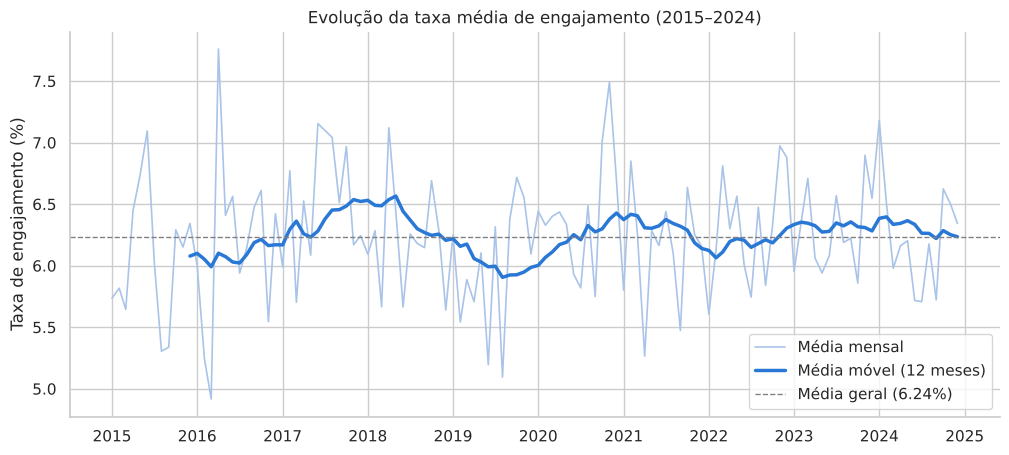

In [15]:
engajamento_mensal = df.groupby("data")["taxa_engajamento"].mean()
media_movel = engajamento_mensal.rolling(12).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(engajamento_mensal.index, engajamento_mensal.values, color="#a9c4e8", linewidth=1.2, label="Média mensal")
ax.plot(media_movel.index, media_movel.values, color=COR_PRINCIPAL, linewidth=2.5, label="Média móvel (12 meses)")
ax.axhline(engajamento_medio, color="gray", linestyle="--", linewidth=1, label=f"Média geral ({engajamento_medio:.2f}%)")
ax.set_title("Evolução da taxa média de engajamento (2015–2024)")
ax.set_ylabel("Taxa de engajamento (%)")
ax.legend(loc="lower right")
salvar_grafico("01_evolucao_engajamento")
plt.show()

In [16]:
df.groupby("ano").agg(
    publicacoes=("perfil", "size"),
    engajamento_medio=("taxa_engajamento", "mean"),
    visualizacoes=("visualizacoes", "sum"),
    alcance_medio=("alcance", "mean"),
)

,publicacoes,engajamento_medio,visualizacoes,alcance_medio
ano,,,,
2015,444,6.08,453120121,"1,261,435.16"
2016,444,6.17,458623769,"1,237,054.86"
2017,444,6.52,429554980,"1,259,283.16"
2018,444,6.21,463613478,"1,227,822.06"
2019,444,5.99,456908419,"1,236,410.18"
2020,444,6.43,438178930,"1,250,510.26"
2021,444,6.14,437482968,"1,333,369.72"
2022,444,6.31,438411954,"1,261,315.86"
2023,444,6.28,443327972,"1,275,584.59"


### 8.2 Comparação entre plataformas

As barras mostram a média e as linhas pretas o intervalo de confiança de 95%. Quando os intervalos se sobrepõem, a diferença entre as plataformas não é estatisticamente relevante.

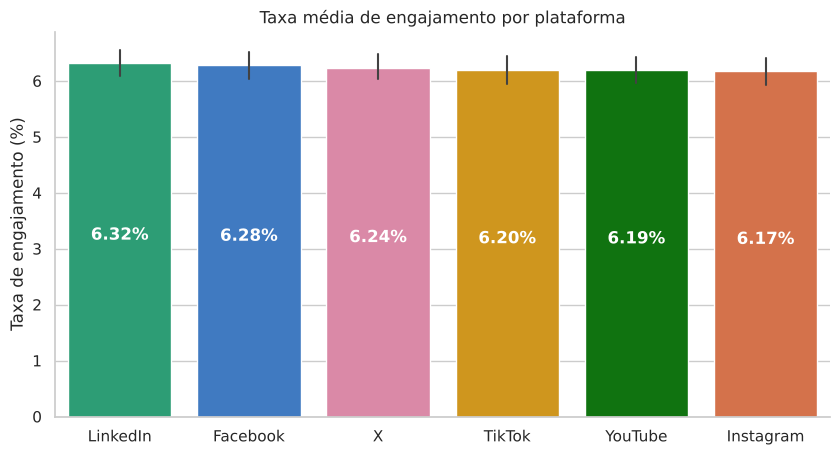

In [17]:
ordem_plataformas = (df.groupby("plataforma", observed=True)["taxa_engajamento"]
                     .mean().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x="plataforma", y="taxa_engajamento", order=ordem_plataformas,
            hue="plataforma", palette=CORES_PLATAFORMA, legend=False, dodge=False,
            errorbar=("ci", 95), seed=42, err_kws={"linewidth": 1.5}, ax=ax)
for barra in ax.patches:
    ax.annotate(f"{barra.get_height():.2f}%", (barra.get_x() + barra.get_width() / 2, barra.get_height() / 2),
                ha="center", color="white", fontweight="bold")
ax.set_title("Taxa média de engajamento por plataforma")
ax.set_xlabel("")
ax.set_ylabel("Taxa de engajamento (%)")
salvar_grafico("02_engajamento_por_plataforma")
plt.show()

In [18]:
resumo_plataforma = df.groupby("plataforma", observed=True).agg(
    publicacoes=("perfil", "size"),
    engajamento_medio=("taxa_engajamento", "mean"),
    alcance_medio=("alcance", "mean"),
    visualizacoes_totais=("visualizacoes", "sum"),
).sort_values("engajamento_medio", ascending=False)

resumo_plataforma

,publicacoes,engajamento_medio,alcance_medio,visualizacoes_totais
plataforma,,,,
LinkedIn,769,6.32,"1,225,002.11",775046986
Facebook,732,6.28,"1,269,678.66",732067576
X,742,6.24,"1,261,162.09",767149975
TikTok,729,6.20,"1,284,305.91",733063533
YouTube,737,6.19,"1,260,940.49",741923403
Instagram,731,6.17,"1,275,362.25",725542139


### 8.3 Comparação entre tipos de conteúdo

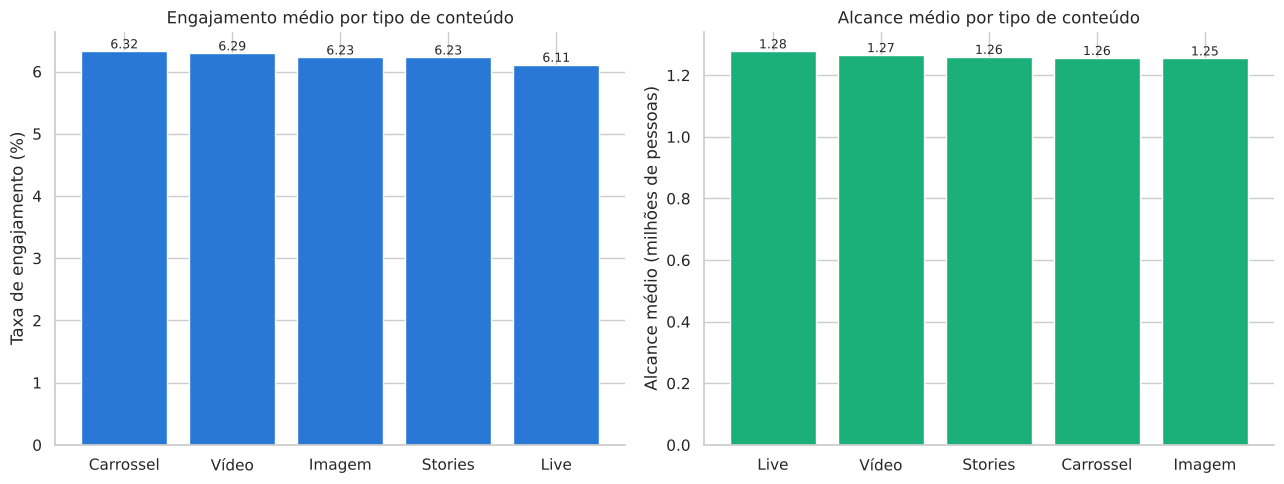

,publicacoes,engajamento_medio,alcance_medio,visualizacoes_medias
tipo_conteudo,,,,
Carrossel,914,6.32,"1,255,929.17","1,004,607.01"
Vídeo,829,6.29,"1,265,292.39","1,012,548.78"
Imagem,961,6.23,"1,254,643.10","993,169.04"
Stories,857,6.23,"1,259,608.74","1,038,797.00"
Live,879,6.11,"1,277,624.86","992,599.98"


In [19]:
resumo_conteudo = df.groupby("tipo_conteudo", observed=True).agg(
    publicacoes=("perfil", "size"),
    engajamento_medio=("taxa_engajamento", "mean"),
    alcance_medio=("alcance", "mean"),
    visualizacoes_medias=("visualizacoes", "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dados = resumo_conteudo.sort_values("engajamento_medio", ascending=False)
axes[0].bar(dados.index, dados["engajamento_medio"], color=COR_PRINCIPAL)
axes[0].set_title("Engajamento médio por tipo de conteúdo")
axes[0].set_ylabel("Taxa de engajamento (%)")

dados = resumo_conteudo.sort_values("alcance_medio", ascending=False)
axes[1].bar(dados.index, dados["alcance_medio"] / 1_000_000, color="#1baf7a")
axes[1].set_title("Alcance médio por tipo de conteúdo")
axes[1].set_ylabel("Alcance médio (milhões de pessoas)")

for ax in axes:
    for barra in ax.patches:
        ax.annotate(f"{barra.get_height():.2f}", (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
salvar_grafico("03_tipos_de_conteudo")
plt.show()

resumo_conteudo.sort_values("engajamento_medio", ascending=False)

### 8.4 Ranking de perfis

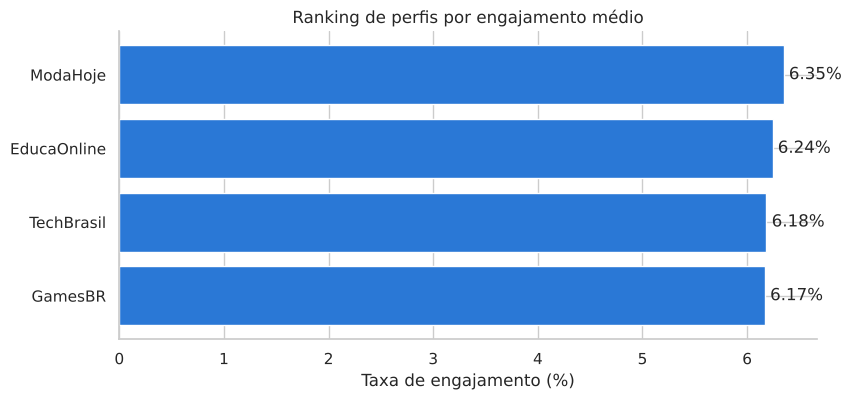

,posicao,engajamento_medio,visualizacoes_totais,interacoes_totais,seguidores_medios
perfil,,,,,
ModaHoje,1,6.35,1095083669,52043894,"486,363.52"
EducaOnline,2,6.24,1179737181,54485239,"511,873.94"
TechBrasil,3,6.18,1060187216,50489645,"494,938.74"
GamesBR,4,6.17,1139785546,54218140,"505,933.49"


In [20]:
ranking_perfis = df.groupby("perfil", observed=True).agg(
    engajamento_medio=("taxa_engajamento", "mean"),
    visualizacoes_totais=("visualizacoes", "sum"),
    interacoes_totais=("interacoes", "sum"),
    seguidores_medios=("seguidores", "mean"),
).sort_values("engajamento_medio", ascending=False)
ranking_perfis.insert(0, "posicao", range(1, len(ranking_perfis) + 1))

fig, ax = plt.subplots(figsize=(9, 4))
dados = ranking_perfis.sort_values("engajamento_medio")
ax.barh(dados.index, dados["engajamento_medio"], color=COR_PRINCIPAL)
for i, valor in enumerate(dados["engajamento_medio"]):
    ax.text(valor + 0.05, i, f"{valor:.2f}%", va="center")
ax.set_title("Ranking de perfis por engajamento médio")
ax.set_xlabel("Taxa de engajamento (%)")
salvar_grafico("04_ranking_perfis")
plt.show()

ranking_perfis

### 8.5 Crescimento de seguidores

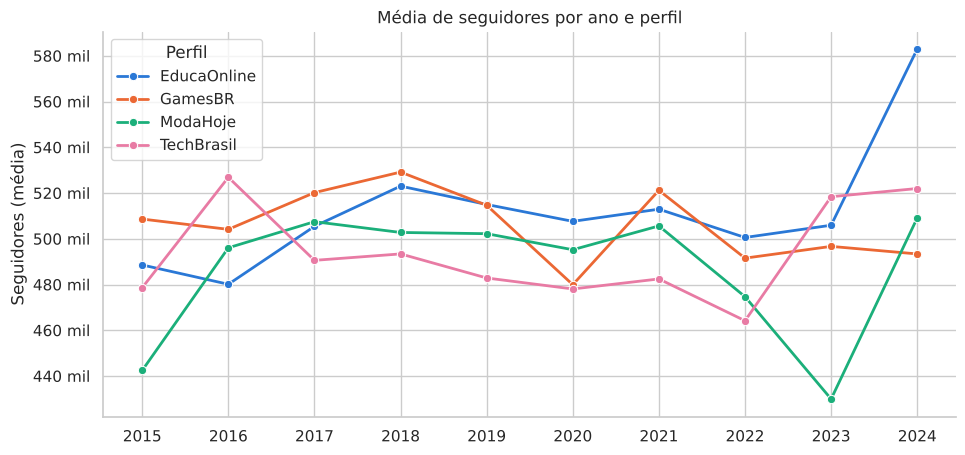

ano,2015,2024,variacao_2015_2024_%
perfil,,,
EducaOnline,"488,554.02","582,961.39",19.32
GamesBR,"508,619.94","493,370.90",-3.00
ModaHoje,"442,461.26","509,098.38",15.06
TechBrasil,"478,631.11","521,978.04",9.06


In [21]:
seguidores_ano = df.groupby(["ano", "perfil"], observed=True)["seguidores"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=seguidores_ano, x="ano", y="seguidores", hue="perfil", marker="o", linewidth=2,
             palette=["#2a78d6", "#eb6834", "#1baf7a", "#e87ba4"], ax=ax)
ax.yaxis.set_major_formatter(lambda valor, _: f"{valor / 1000:.0f} mil")
ax.set_title("Média de seguidores por ano e perfil")
ax.set_xlabel("")
ax.set_ylabel("Seguidores (média)")
ax.set_xticks(range(2015, 2025))
ax.legend(title="Perfil")
salvar_grafico("05_seguidores_por_ano")
plt.show()

variacao = seguidores_ano.pivot(index="perfil", columns="ano", values="seguidores")
variacao["variacao_2015_2024_%"] = (variacao[2024] / variacao[2015] - 1) * 100
variacao[[2015, 2024, "variacao_2015_2024_%"]]

### 8.6 Horário de publicação

Heatmap com a taxa média de engajamento em cada combinação de horário e plataforma (quanto mais escuro, maior o engajamento).

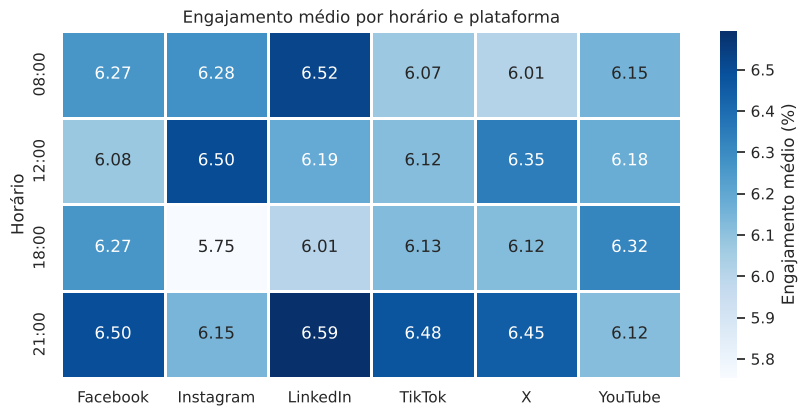

In [22]:
tabela_horario = df.pivot_table(index="horario_publicacao", columns="plataforma",
                                values="taxa_engajamento", aggfunc="mean", observed=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(tabela_horario, annot=True, fmt=".2f", cmap="Blues", linewidths=2, linecolor="white",
            cbar_kws={"label": "Engajamento médio (%)"}, ax=ax)
ax.set_title("Engajamento médio por horário e plataforma")
ax.set_xlabel("")
ax.set_ylabel("Horário")
salvar_grafico("06_heatmap_horario")
plt.show()

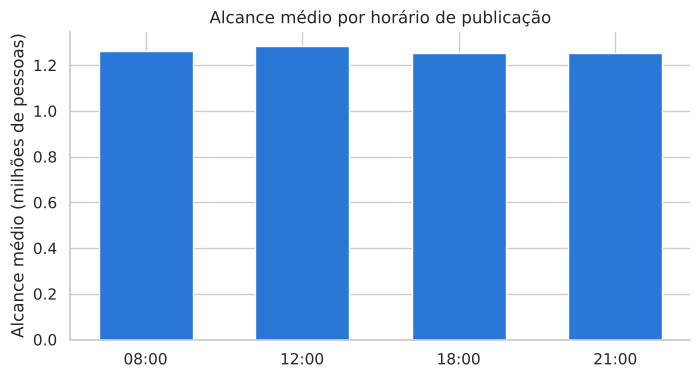

,publicacoes,engajamento_medio,alcance_medio
horario_publicacao,,,
08:00,1124,6.22,"1,264,293.34"
12:00,1069,6.24,"1,283,223.04"
18:00,1113,6.10,"1,251,778.99"
21:00,1134,6.38,"1,251,335.51"


In [23]:
resumo_horario = df.groupby("horario_publicacao").agg(
    publicacoes=("perfil", "size"),
    engajamento_medio=("taxa_engajamento", "mean"),
    alcance_medio=("alcance", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(resumo_horario.index, resumo_horario["alcance_medio"] / 1_000_000, color=COR_PRINCIPAL, width=0.6)
ax.set_title("Alcance médio por horário de publicação")
ax.set_ylabel("Alcance médio (milhões de pessoas)")
salvar_grafico("07_alcance_por_horario")
plt.show()

resumo_horario

### 8.7 Seguidores x engajamento

Será que perfis com mais seguidores engajam mais? O gráfico de dispersão e o coeficiente de correlação de Pearson ajudam a responder.

Correlação entre seguidores e engajamento: -0.014

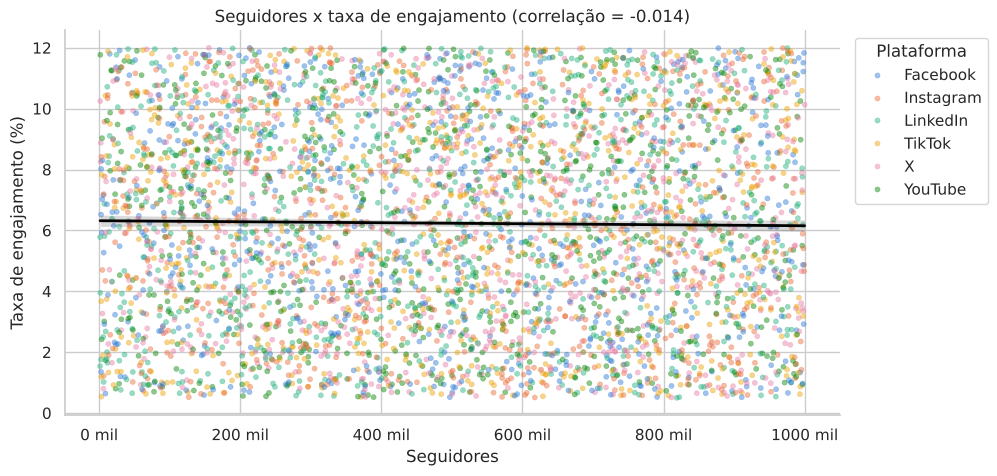

In [24]:
correlacao_seg = df["seguidores"].corr(df["taxa_engajamento"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x="seguidores", y="taxa_engajamento", hue="plataforma", palette=CORES_PLATAFORMA,
                alpha=0.45, s=14, edgecolor=None, ax=ax)
sns.regplot(data=df, x="seguidores", y="taxa_engajamento", scatter=False, color="black",
            line_kws={"linewidth": 2}, ax=ax)
ax.xaxis.set_major_formatter(lambda valor, _: f"{valor / 1000:.0f} mil")
ax.set_title(f"Seguidores x taxa de engajamento (correlação = {correlacao_seg:.3f})")
ax.set_xlabel("Seguidores")
ax.set_ylabel("Taxa de engajamento (%)")
ax.legend(title="Plataforma", bbox_to_anchor=(1.01, 1), loc="upper left")
salvar_grafico("08_seguidores_x_engajamento")
plt.show()

print(f"Correlação entre seguidores e engajamento: {correlacao_seg:.3f}")

### 8.8 Frequência de postagem x alcance

Para cada perfil e mês, contamos quantas publicações foram feitas e calculamos o alcance médio delas.

Correlação entre frequência de postagem e alcance: -0.019

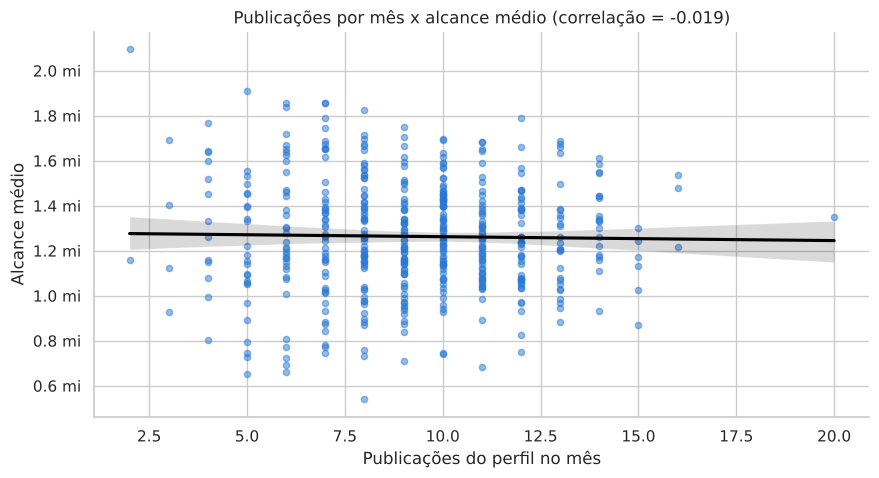

In [25]:
frequencia = df.groupby(["perfil", "ano_mes"], observed=True).agg(
    publicacoes_no_mes=("alcance", "size"),
    alcance_medio=("alcance", "mean"),
).reset_index()

correlacao_freq = frequencia["publicacoes_no_mes"].corr(frequencia["alcance_medio"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(data=frequencia, x="publicacoes_no_mes", y="alcance_medio", color=COR_PRINCIPAL,
            scatter_kws={"alpha": 0.5, "s": 20}, line_kws={"color": "black"}, ax=ax)
ax.yaxis.set_major_formatter(lambda valor, _: f"{valor / 1_000_000:.1f} mi")
ax.set_title(f"Publicações por mês x alcance médio (correlação = {correlacao_freq:.3f})")
ax.set_xlabel("Publicações do perfil no mês")
ax.set_ylabel("Alcance médio")
salvar_grafico("09_frequencia_x_alcance")
plt.show()

print(f"Correlação entre frequência de postagem e alcance: {correlacao_freq:.3f}")

### 8.9 Correlação entre as métricas

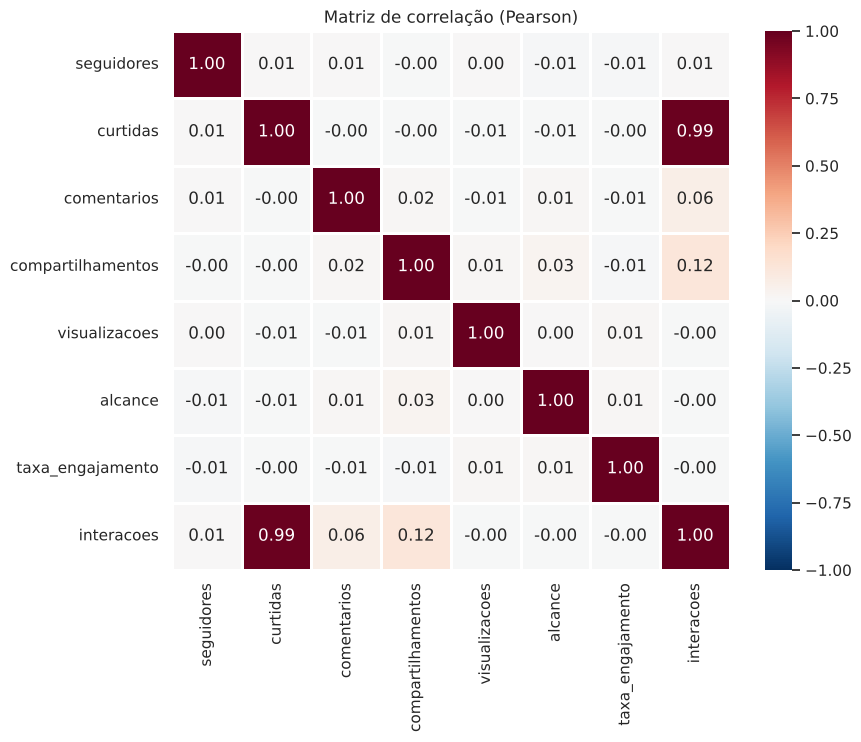

seguidores          -0.01
visualizacoes        0.01
compartilhamentos   -0.01
alcance              0.01
comentarios         -0.01
interacoes          -0.00
curtidas            -0.00
Name: taxa_engajamento, dtype: float64

In [26]:
matriz_correlacao = df[colunas_numericas + ["interacoes"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            linewidths=1, linecolor="white", ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
salvar_grafico("10_matriz_correlacao")
plt.show()

matriz_correlacao["taxa_engajamento"].drop("taxa_engajamento").sort_values(key=abs, ascending=False)

### 8.10 Conteúdos virais

Percentual de publicações de cada plataforma e de cada formato que ficaram entre as 5% mais vistas.

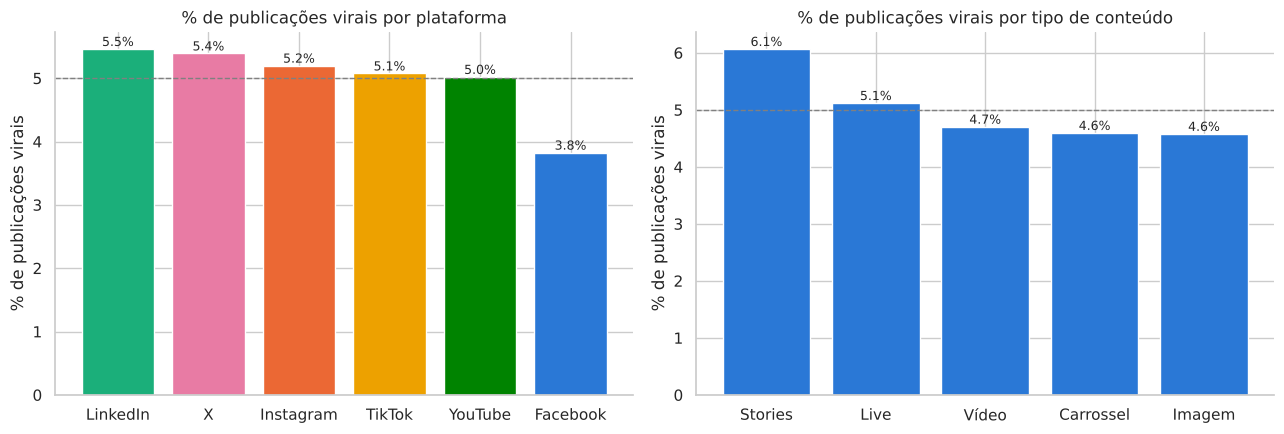

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

viral_plataforma = df.groupby("plataforma", observed=True)["viral"].mean().sort_values(ascending=False) * 100
axes[0].bar(viral_plataforma.index, viral_plataforma.values,
            color=[CORES_PLATAFORMA[p] for p in viral_plataforma.index])
axes[0].set_title("% de publicações virais por plataforma")

viral_conteudo = df.groupby("tipo_conteudo", observed=True)["viral"].mean().sort_values(ascending=False) * 100
axes[1].bar(viral_conteudo.index, viral_conteudo.values, color=COR_PRINCIPAL)
axes[1].set_title("% de publicações virais por tipo de conteúdo")

for ax in axes:
    ax.axhline(5, color="gray", linestyle="--", linewidth=1)
    ax.set_ylabel("% de publicações virais")
    for barra in ax.patches:
        ax.annotate(f"{barra.get_height():.1f}%", (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
salvar_grafico("11_conteudos_virais")
plt.show()

In [28]:
top_virais = df.sort_values("visualizacoes", ascending=False).head(10)
top_virais[["data", "plataforma", "perfil", "tipo_conteudo", "horario_publicacao",
            "visualizacoes", "alcance", "taxa_engajamento"]]

,data,plataforma,perfil,tipo_conteudo,horario_publicacao,visualizacoes,alcance,taxa_engajamento
2513,2020-08-01,Instagram,GamesBR,Imagem,18:00,1998805,2096211,3.99
118,2015-04-01,Facebook,EducaOnline,Vídeo,18:00,1998227,503435,1.28
4176,2024-05-01,YouTube,EducaOnline,Stories,08:00,1997386,1548825,11.53
3684,2023-04-01,X,GamesBR,Live,18:00,1997255,1145789,11.07
482,2016-02-01,LinkedIn,EducaOnline,Stories,08:00,1996871,184290,6.87
2308,2020-03-01,TikTok,TechBrasil,Live,18:00,1996349,474942,10.84
3030,2021-10-01,LinkedIn,GamesBR,Imagem,21:00,1995239,2192786,7.25
1727,2018-11-01,Instagram,EducaOnline,Stories,21:00,1994876,1279737,11.20
1323,2017-12-01,TikTok,TechBrasil,Imagem,08:00,1994830,1044615,0.54
1856,2019-03-01,YouTube,ModaHoje,Stories,12:00,1993686,1190874,5.20


### 8.11 Melhores combinações de perfil e formato ("campanhas")

A base não tem uma coluna de campanha, então cada combinação de **perfil + tipo de conteúdo** foi tratada como uma estratégia de campanha.

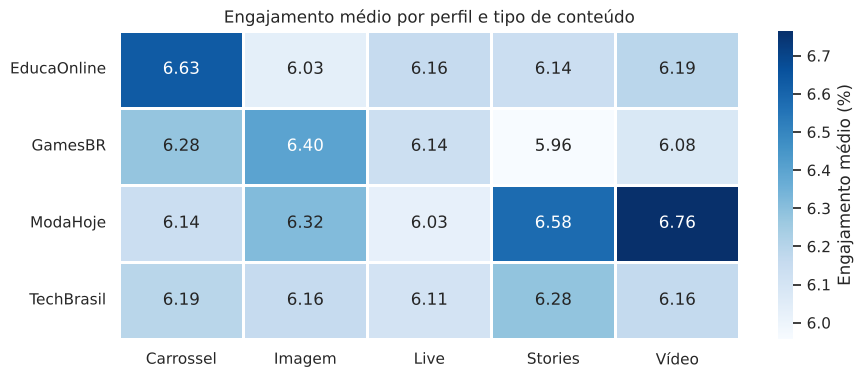

,,publicacoes,engajamento_medio,alcance_medio
perfil,tipo_conteudo,,,
ModaHoje,Vídeo,200,6.76,"1,261,153.39"
EducaOnline,Carrossel,261,6.63,"1,287,216.43"
ModaHoje,Stories,187,6.58,"1,248,460.52"
GamesBR,Imagem,238,6.40,"1,273,894.24"
ModaHoje,Imagem,240,6.32,"1,214,947.59"


In [29]:
tabela_campanhas = df.pivot_table(index="perfil", columns="tipo_conteudo", values="taxa_engajamento",
                                  aggfunc="mean", observed=True)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(tabela_campanhas, annot=True, fmt=".2f", cmap="Blues", linewidths=2, linecolor="white",
            cbar_kws={"label": "Engajamento médio (%)"}, ax=ax)
ax.set_title("Engajamento médio por perfil e tipo de conteúdo")
ax.set_xlabel("")
ax.set_ylabel("")
salvar_grafico("12_perfil_x_formato")
plt.show()

melhores_campanhas = (df.groupby(["perfil", "tipo_conteudo"], observed=True)
                      .agg(publicacoes=("taxa_engajamento", "size"),
                           engajamento_medio=("taxa_engajamento", "mean"),
                           alcance_medio=("alcance", "mean"))
                      .sort_values("engajamento_medio", ascending=False))
melhores_campanhas.head(5)

## 9. Interpretação dos resultados

**1. Quais plataformas apresentam maior engajamento?**
O **LinkedIn** tem a maior taxa média (6,32%) e o **Instagram** a menor (6,17%). A diferença entre a primeira e a última é de apenas **0,15 ponto percentual**, e os intervalos de confiança se sobrepõem. Ou seja, na prática as seis plataformas têm desempenho muito parecido nesta base.

**2. Quais tipos de conteúdo possuem melhor desempenho?**
Em engajamento, **Carrossel** lidera (6,32%) e **Live** fica por último (6,11%). Em alcance, **Live** tem o maior alcance médio (1,28 milhões de pessoas). De novo, as diferenças são pequenas (menos de 0,3 p.p. no engajamento).

**3. Existem horários mais favoráveis?**
As publicações das **21:00** têm o maior engajamento médio (6,38%) e as das **18:00** o menor (6,10%). Já o maior alcance médio é das **12:00**. O heatmap mostra que o melhor horário muda de plataforma para plataforma, então não existe um horário que seja o melhor para todas.

**4. Como os seguidores evoluíram?**
A média de seguidores oscila ao longo dos anos sem uma tendência clara de crescimento. Comparando 2015 com 2024, o perfil **EducaOnline** foi o que mais cresceu (19,3%), enquanto **GamesBR** teve a menor variação (-3,0%). O engajamento médio anual também oscila entre 5,99% e 6,52%, sem subir ou cair de forma consistente.

**5. Existe relação entre frequência de postagem e alcance?**
Não. A correlação entre o número de publicações do perfil no mês e o alcance médio é de **-0,019**, praticamente zero. Postar mais não aumentou o alcance de cada publicação.

**6. Quais campanhas apresentaram melhores resultados?**
A melhor combinação foi **ModaHoje + Vídeo** (6,76% de engajamento médio), seguida de EducaOnline + Carrossel e ModaHoje + Stories. Essas combinações são as mais promissoras para testar em campanhas futuras.

**7. Quais métricas são mais relevantes para o engajamento?**
Nenhuma métrica isolada explica a taxa de engajamento nesta base: a maior correlação com a taxa é de apenas 0,014 (em módulo). Curtidas, comentários, compartilhamentos, alcance e seguidores variam de forma independente. A correlação entre seguidores e engajamento é de -0,014, então ter mais seguidores **não** garante mais engajamento.

**Conteúdos virais:** a plataforma com maior proporção de virais é **LinkedIn** (5,5% das publicações) e o formato é **Stories** (6,1%), contra 5% esperados se tudo fosse igual.

## 10. Conclusão

- A base estava completa (sem nulos, duplicados ou outliers). O principal tratamento foi converter tipos, criar novas colunas (interações, trimestre, faixa de seguidores, viral) e marcar as poucas linhas inconsistentes.
- O engajamento ficou **estável ao longo dos dez anos** e **muito parecido entre plataformas, formatos, horários e perfis**. As diferenças encontradas são de décimos de ponto percentual.
- Seguidores, frequência de postagem e as demais métricas **não têm correlação** com a taxa de engajamento.
- Isso faz sentido porque a base é **simulada com valores aleatórios**: não existe um padrão "escondido" para encontrar. Um resultado importante da análise é justamente mostrar que as diferenças são pequenas e não justificariam, sozinhas, mudar a estratégia de uma empresa.

**Recomendações (para dados reais):**

1. Priorizar as combinações de perfil e formato com melhor desempenho e testá-las em campanhas (testes A/B).
2. Avaliar o horário de publicação **por plataforma**, e não com uma regra única.
3. Acompanhar engajamento e alcance, e não só o número de seguidores.
4. Coletar dados de campanhas e de investimento para medir retorno, o que esta base não permite.

Os mesmos dados podem ser explorados de forma interativa no dashboard em Streamlit (`app.py`).